In [3]:
import os, sys
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Force stdout to flush immediately so every print shows inline
class Unbuffered:
    def __init__(self, stream): self.stream = stream
    def write(self, data): self.stream.write(data); self.stream.flush()
    def writelines(self, lines): self.stream.writelines(lines); self.stream.flush()
    def __getattr__(self, attr): return getattr(self.stream, attr)

sys.stdout = Unbuffered(sys.stdout)
print("Inline printing enabled.")


Inline printing enabled.


In [4]:
import copy, random
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from peft import get_peft_model, LoraConfig

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working/lung_fedbn"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Auto-detect DATA_DIR: walk /kaggle/input to find the folder containing
# the 3 class subfolders, regardless of how Kaggle mounted the dataset.
CLASS_NAMES_NORM = {"bengin cases", "malignant cases", "normal cases"}

def find_data_dir(search_root="/kaggle/input"):
    for dirpath, dirnames, _ in os.walk(search_root):
        subdirs = {d.lower() for d in dirnames}
        if CLASS_NAMES_NORM.issubset(subdirs):
            return dirpath
    return None

DATA_DIR = find_data_dir()
if DATA_DIR is None:
    print("[ERROR] Could not auto-detect DATA_DIR. Contents of /kaggle/input:")
    for root, dirs, files in os.walk("/kaggle/input"):
        level = root.replace("/kaggle/input", "").count(os.sep)
        if level > 3:
            continue
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
    raise RuntimeError("DATA_DIR not found. Check dataset mount above.")

print(f"DATA_DIR   : {DATA_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
LR           = 1e-4
SEED         = 42
NUM_CLASSES  = 3
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_FOLDS      = 5
TEST_SIZE    = 0.10

NUM_CLIENTS  = 3
FL_ROUNDS    = 5
LOCAL_EPOCHS = 4

CLASS_NAMES  = ["Bengin cases", "Malignant cases", "Normal cases"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

LOCAL_EFFICIENTNET_B0 = "/kaggle/input/efficientnet-b0-weights/efficientnet_b0_rwightman-3dd342df.pth"

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Config → IMG:{IMG_SIZE} BS:{BATCH_SIZE} LR:{LR} Folds:{N_FOLDS} "
      f"Clients:{NUM_CLIENTS} Rounds:{FL_ROUNDS} LocalEpochs:{LOCAL_EPOCHS}")

DATA_DIR   : /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset
OUTPUT_DIR : /kaggle/working/lung_fedbn
Device: cuda
Config → IMG:224 BS:32 LR:0.0001 Folds:5 Clients:3 Rounds:5 LocalEpochs:4


In [5]:
def collect_samples(root_dir):
    norm     = lambda s: s.lower().replace(" ", "")
    name_map = {norm(c): i for i, c in enumerate(CLASS_NAMES)}
    samples  = []
    for entry in sorted(os.listdir(root_dir)):
        entry_path = os.path.join(root_dir, entry)
        if not os.path.isdir(entry_path):
            continue
        key = norm(entry)
        if key not in name_map:
            print(f"  [WARN] Skipping unrecognised folder: {entry!r}")
            continue
        label = name_map[key]
        files = [fn for fn in os.listdir(entry_path) if fn.lower().endswith((".jpg",".jpeg",".png"))]
        samples.extend((os.path.join(entry_path, fn), label) for fn in files)
        print(f"  Loaded class '{CLASS_NAMES[label]}': {len(files)} images")
    return samples

print("Collecting samples...")
all_samples = collect_samples(DATA_DIR)
all_paths   = [s[0] for s in all_samples]
all_labels  = [s[1] for s in all_samples]

trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SIZE, random_state=SEED, stratify=all_labels
)
trainval_samples = list(zip(trainval_paths, trainval_labels))
test_samples     = list(zip(test_paths, test_labels))

print(f"\nTotal samples    : {len(all_samples)}")
print(f"Train+Val (90%)  : {len(trainval_samples)}")
print(f"Test held-out(10%): {len(test_samples)}")
print(f"Class dist (train+val): {dict(sorted(Counter(trainval_labels).items()))}")
print(f"Class dist (test)     : {dict(sorted(Counter(test_labels).items()))}")


  Loaded class 'Bengin cases': 120 images
  Loaded class 'Malignant cases': 561 images
  Loaded class 'Normal cases': 416 images

Total samples    : 1097
Train+Val (90%)  : 987
Test held-out(10%): 110
Class dist (train+val): {0: 108, 1: 505, 2: 374}
Class dist (test)     : {0: 12, 1: 56, 2: 42}


In [6]:
def preprocess_image_pil(img_pil):
    img   = np.array(img_pil.convert("RGB"))
    gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq    = clahe.apply(gray)
    edge  = cv2.Canny(eq, 80, 160)
    return Image.fromarray(np.stack([edge, edge, edge], axis=-1))

raw_train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(), T.RandomRotation(10),
    T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
raw_eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
pre_train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(), T.RandomRotation(10),
    T.ToTensor(), T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
pre_eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(), T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
print("Transforms defined.")


Transforms defined.


In [7]:
class LungHybridDataset(Dataset):
    def __init__(self, samples, raw_tfms, pre_tfms):
        self.samples  = samples
        self.raw_tfms = raw_tfms
        self.pre_tfms = pre_tfms

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img     = Image.open(path).convert("RGB")
        pre_img = preprocess_image_pil(img)
        return (self.raw_tfms(img),
                self.pre_tfms(pre_img),
                torch.tensor(label, dtype=torch.long))

test_ds     = LungHybridDataset(test_samples, raw_eval_tfms, pre_eval_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test dataset  : {len(test_ds)} samples  ({len(test_loader)} batches)")
print("Test loader locked — will only be used in the final evaluation cell.")


Test dataset  : 110 samples  (4 batches)
Test loader locked — will only be used in the final evaluation cell.


In [8]:
class AttentionFusion(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(inplace=True),
            nn.Linear(dim, dim), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.net(x)


class PreBranch(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128),nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(128, out_dim), nn.ReLU(inplace=True), nn.Dropout(0.3))
    def forward(self, x):
        return self.fc(self.net(x))


def apply_lora_to_efficientnet(eff, r=8, lora_alpha=16, lora_dropout=0.05):
    # Freeze entire backbone first
    for p in eff.parameters():
        p.requires_grad_(False)

    # Unfreeze last 2 MBConv blocks for fine-tuning
    for p in eff.features[-2:].parameters():
        p.requires_grad_(True)

    # Replace classifier with a named Linear so LoRA can target it by name
    in_feats = eff.classifier[1].in_features
    eff.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_feats, in_feats)   # named "fc_head" via module replacement below
    )
    for p in eff.classifier.parameters():
        p.requires_grad_(True)

    # LoRA targets Linear layers whose full dotted key ends with "classifier.1"
    # We verify by printing matched modules before applying
    matched = [name for name, mod in eff.named_modules()
               if isinstance(mod, nn.Linear) and "classifier" in name]
    print(f"  LoRA target candidates: {matched}")

    lora_cfg = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=["classifier.1"],   # exact dotted path to the Linear
        bias="none",
    )
    eff = get_peft_model(eff, lora_cfg)
    print("LoRA applied:")
    eff.print_trainable_parameters()
    return eff


class HybridLungCancerNet(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        eff = models.efficientnet_b0(weights=None)
        if pretrained:
            if os.path.isfile(LOCAL_EFFICIENTNET_B0):
                eff.load_state_dict(torch.load(LOCAL_EFFICIENTNET_B0, map_location="cpu"))
                print("[INFO] Loaded pretrained weights from local path.")
            else:
                try:
                    w = models.EfficientNet_B0_Weights.IMAGENET1K_V1
                    eff.load_state_dict(w.get_state_dict(progress=True))
                    print("[INFO] Downloaded pretrained weights.")
                except Exception as e:
                    print(f"[WARN] Pretrained unavailable ({e}). Random init.")

        eff = apply_lora_to_efficientnet(eff, r=8, lora_alpha=16)

        self.raw_features = eff.features
        self.raw_pool     = nn.AdaptiveAvgPool2d((1,1))
        self.raw_fc       = nn.Sequential(
            nn.Flatten(), nn.Linear(1280, 256), nn.ReLU(inplace=True), nn.Dropout(0.3)
        )
        self.pre_branch   = PreBranch(out_dim=256)
        self.fusion_attn  = AttentionFusion(dim=512)
        self.classifier   = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, raw_x, pre_x):
        raw_feat = self.raw_fc(self.raw_pool(self.raw_features(raw_x)))
        pre_feat = self.pre_branch(pre_x)
        fused    = self.fusion_attn(torch.cat([raw_feat, pre_feat], dim=1))
        return self.classifier(fused)

print("Building model for smoke test...")
_m = HybridLungCancerNet(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
total_params     = sum(p.numel() for p in _m.parameters())
trainable_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)")
del _m


Building model for smoke test...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]

[INFO] Downloaded pretrained weights.


  LoRA target candidates: ['classifier.1']
LoRA applied:
trainable params: 20,480 || all params: 5,667,708 || trainable%: 0.3613
Total params    : 5,119,615
Trainable params: 1,112,067  (21.72%)


In [9]:
def run_one_epoch(model, loader, criterion, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    for raw_x, pre_x, y in pbar:
        raw_x, pre_x, y = raw_x.to(DEVICE), pre_x.to(DEVICE), y.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            logits = model(raw_x, pre_x)
            loss   = criterion(logits, y)
            if is_train:
                loss.backward(); optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(y.detach().cpu().tolist())

        # Live loss in progress bar
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_labels, all_preds

print("run_one_epoch defined with tqdm progress bars.")


run_one_epoch defined with tqdm progress bars.


In [10]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
FOLD_EPOCHS  = 20

for fold, (train_idx, val_idx) in enumerate(skf.split(trainval_paths, trainval_labels), 1):
    print(f"\n{'='*65}")
    print(f"  FOLD {fold}/{N_FOLDS}  |  train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'='*65}")

    train_fold = [trainval_samples[i] for i in train_idx]
    val_fold   = [trainval_samples[i] for i in val_idx]

    train_ds_f = LungHybridDataset(train_fold, raw_train_tfms, pre_train_tfms)
    val_ds_f   = LungHybridDataset(val_fold,   raw_eval_tfms,  pre_eval_tfms)
    train_loader_f = DataLoader(train_ds_f, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader_f   = DataLoader(val_ds_f,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    fold_labels_list = [trainval_labels[i] for i in train_idx]
    class_counts     = np.bincount(fold_labels_list, minlength=NUM_CLASSES)
    class_weights_t  = torch.tensor(
        len(fold_labels_list) / (NUM_CLASSES * class_counts), dtype=torch.float32
    ).to(DEVICE)
    print(f"  Class counts : {dict(zip(CLASS_NAMES, class_counts.tolist()))}")
    print(f"  Class weights: {dict(zip(CLASS_NAMES, class_weights_t.cpu().tolist()))}")

    model     = HybridLungCancerNet(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    fold_history  = []

    epoch_pbar = tqdm(range(1, FOLD_EPOCHS + 1), desc=f"Fold {fold} epochs", dynamic_ncols=True)
    for epoch in epoch_pbar:
        tr_loss, tr_acc, tr_f1, _, _ = run_one_epoch(model, train_loader_f, criterion, optimizer,
                                                       desc=f"F{fold} Ep{epoch:02d} Train")
        va_loss, va_acc, va_f1, _, _ = run_one_epoch(model, val_loader_f,   criterion,
                                                       desc=f"F{fold} Ep{epoch:02d} Val  ")
        scheduler.step(va_loss)
        fold_history.append([epoch, tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1])

        epoch_pbar.set_postfix(tr_loss=f"{tr_loss:.4f}", tr_acc=f"{tr_acc:.4f}",
                               va_loss=f"{va_loss:.4f}", va_acc=f"{va_acc:.4f}")
        print(f"  Ep {epoch:02d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} tr_f1={tr_f1:.4f} "
              f"| val_loss={va_loss:.4f} val_acc={va_acc:.4f} val_f1={va_f1:.4f}")

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"fold{fold}_best.pt"))
            print(f"    ✓ New best val_loss={va_loss:.4f} — checkpoint saved")

    pd.DataFrame(fold_history,
                 columns=["epoch","train_loss","train_acc","train_f1","val_loss","val_acc","val_f1"]
                 ).to_csv(os.path.join(OUTPUT_DIR, f"fold{fold}_history.csv"), index=False)

    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f"fold{fold}_best.pt"), map_location=DEVICE))
    va_loss, va_acc, va_f1, va_y, va_p = run_one_epoch(model, val_loader_f, criterion,
                                                        desc=f"Fold {fold} final eval")
    fold_results.append({"fold": fold, "val_loss": va_loss, "val_acc": va_acc, "val_f1": va_f1})
    print(f"\n  Fold {fold} FINAL → loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")
    print(classification_report(va_y, va_p, target_names=CLASS_NAMES, digits=4))

results_df = pd.DataFrame(fold_results)
results_df.to_csv(os.path.join(OUTPUT_DIR, "kfold_summary.csv"), index=False)
print("\n" + "="*65)
print("  K-FOLD SUMMARY")
print("="*65)
print(results_df.to_string(index=False))
print(f"\n  Mean Val Acc : {results_df.val_acc.mean():.4f} ± {results_df.val_acc.std():.4f}")
print(f"  Mean Val F1  : {results_df.val_f1.mean():.4f} ± {results_df.val_f1.std():.4f}")



  FOLD 1/5  |  train=789  val=198
  Class counts : {'Bengin cases': 86, 'Malignant cases': 404, 'Normal cases': 299}
  Class weights: {'Bengin cases': 3.0581395626068115, 'Malignant cases': 0.6509901285171509, 'Normal cases': 0.8795986771583557}
[INFO] Downloaded pretrained weights.
  LoRA target candidates: ['classifier.1']
LoRA applied:
trainable params: 20,480 || all params: 5,667,708 || trainable%: 0.3613


Fold 1 epochs:   0%|          | 0/20 [00:00<?, ?it/s]

F1 Ep01 Train:   0%|          | 0/25 [00:00<?, ?it/s]

F1 Ep01 Val  :   0%|          | 0/7 [00:00<?, ?it/s]

  Ep 01 | tr_loss=1.0693 tr_acc=0.7009 tr_f1=0.5118 | val_loss=1.0563 val_acc=0.8333 val_f1=0.5832
    ✓ New best val_loss=1.0563 — checkpoint saved


...

F5 Ep20 Train:   0%|          | 0/25 [00:00<?, ?it/s]

F5 Ep20 Val  :   0%|          | 0/7 [00:00<?, ?it/s]

  Ep 20 | tr_loss=0.3461 tr_acc=0.8722 tr_f1=0.8025 | val_loss=0.4191 val_acc=0.9036 val_f1=0.8354


Fold 5 final eval:   0%|          | 0/7 [00:00<?, ?it/s]


  Fold 5 FINAL → loss=0.4069 acc=0.8528 f1=0.7821
                 precision    recall  f1-score   support

   Bengin cases     0.4595    0.7727    0.5763        22
Malignant cases     0.9798    0.9604    0.9700       101
   Normal cases     0.8852    0.7297    0.8000        74

       accuracy                         0.8528       197
      macro avg     0.7748    0.8210    0.7821       197
   weighted avg     0.8862    0.8528    0.8622       197


  K-FOLD SUMMARY
 fold  val_loss  val_acc   val_f1
    1  0.496326 0.853535 0.780947
    2  0.356738 0.868687 0.789341
    3  0.358973 0.837563 0.761431
    4  0.328075 0.852792 0.781313
    5  0.406855 0.852792 0.782090

  Mean Val Acc : 0.8531 ± 0.0110
  Mean Val F1  : 0.7790 ± 0.0104


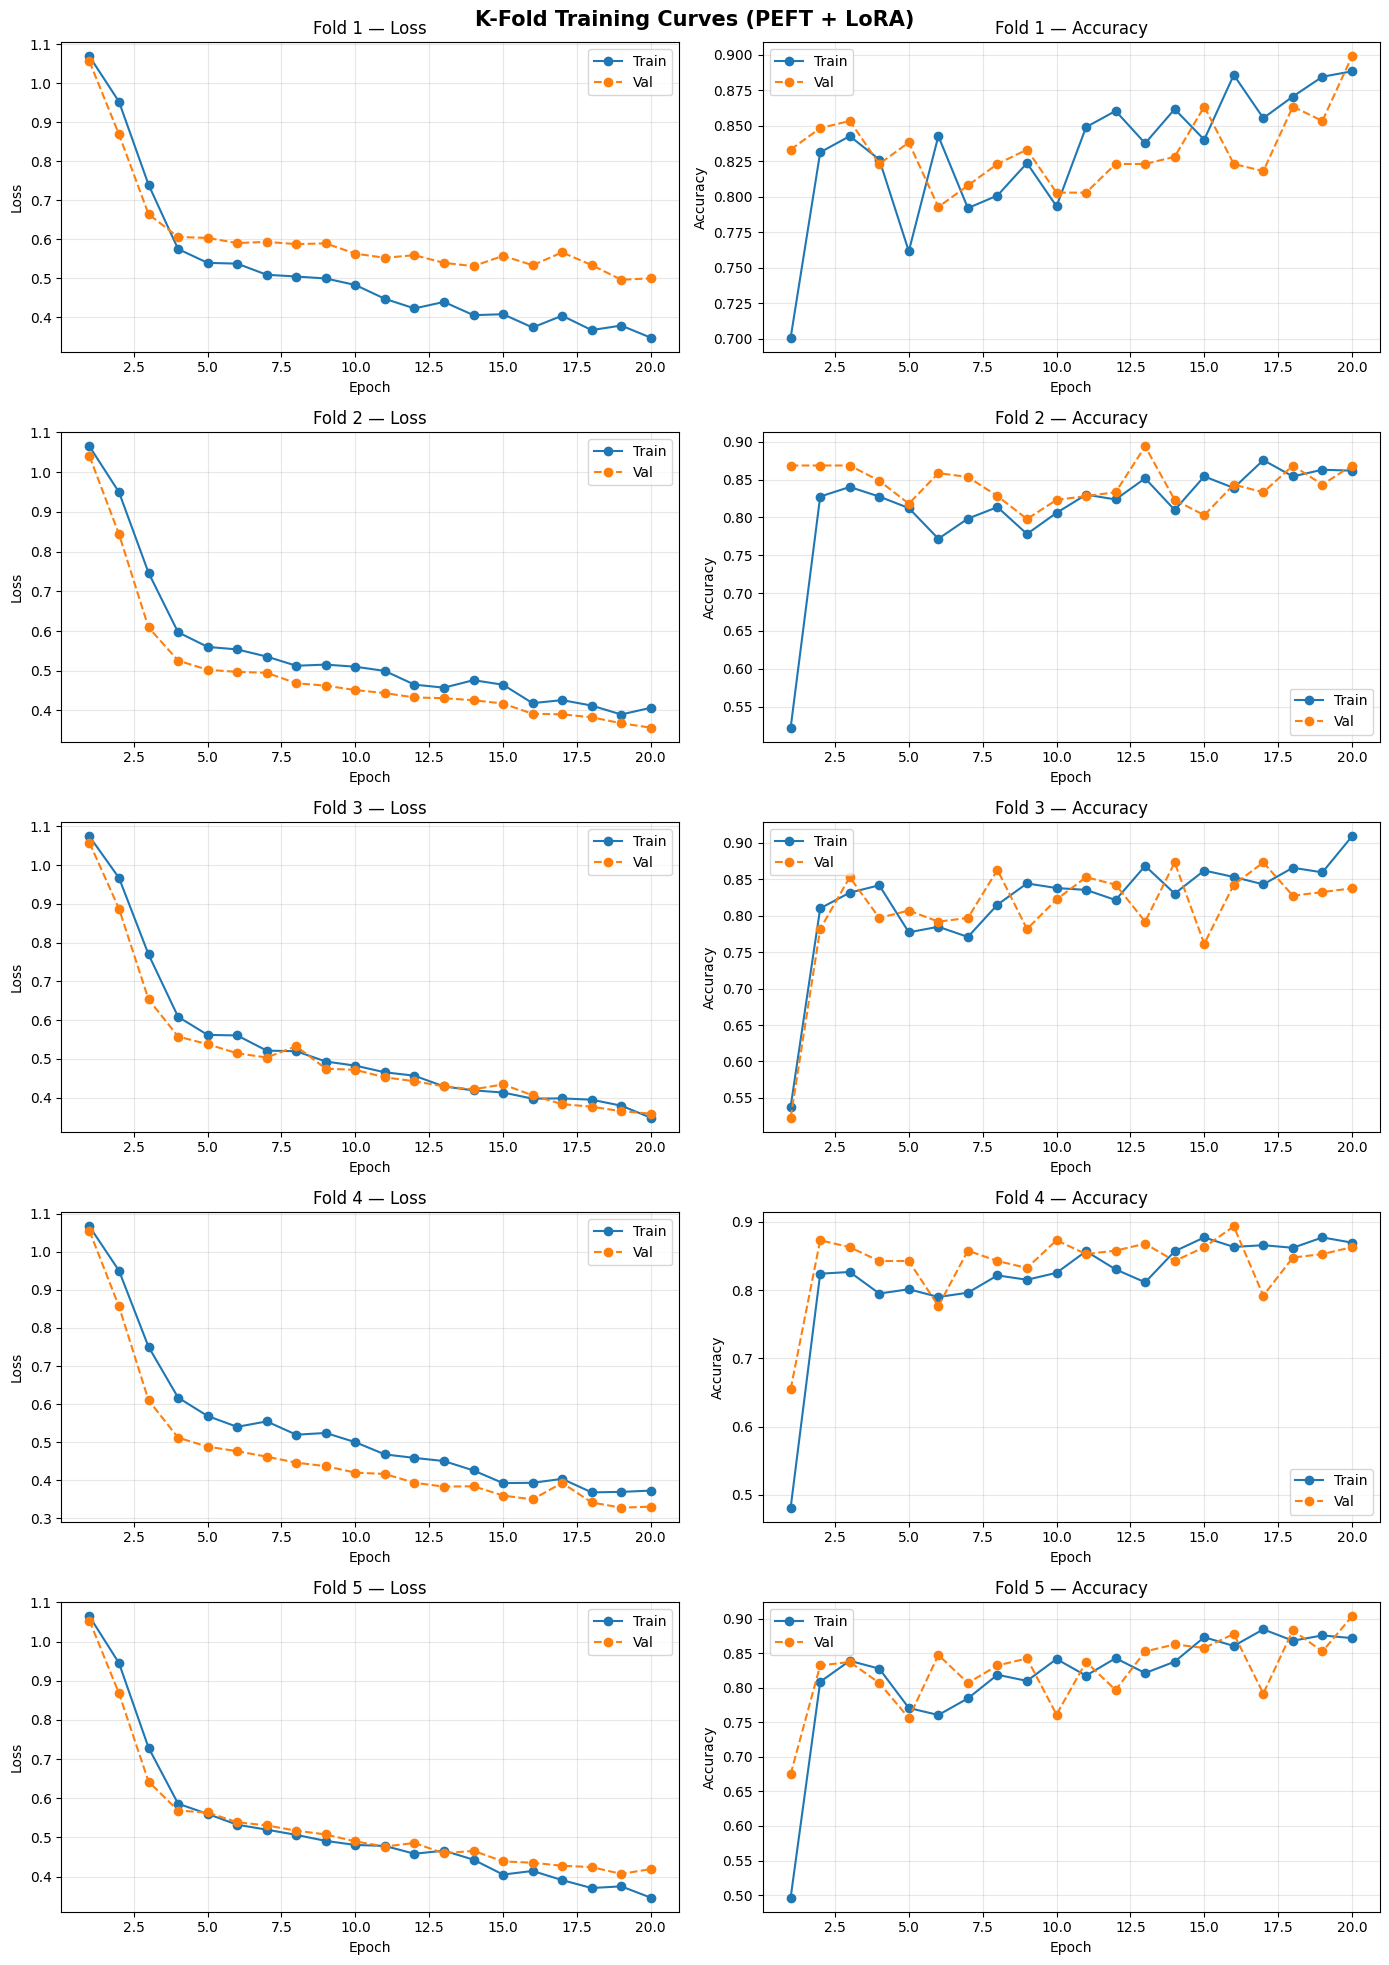

K-Fold curves saved.


In [11]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, 4 * N_FOLDS))

for fold in range(1, N_FOLDS + 1):
    df = pd.read_csv(os.path.join(OUTPUT_DIR, f"fold{fold}_history.csv"))
    ax_loss, ax_acc = axes[fold-1]

    ax_loss.plot(df.epoch, df.train_loss, label="Train", marker="o", linewidth=1.5)
    ax_loss.plot(df.epoch, df.val_loss,   label="Val",   marker="o", linewidth=1.5, linestyle="--")
    ax_loss.set_title(f"Fold {fold} — Loss"); ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(df.epoch, df.train_acc, label="Train", marker="o", linewidth=1.5)
    ax_acc.plot(df.epoch, df.val_acc,   label="Val",   marker="o", linewidth=1.5, linestyle="--")
    ax_acc.set_title(f"Fold {fold} — Accuracy"); ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

plt.suptitle("K-Fold Training Curves (PEFT + LoRA)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_curves.png"), dpi=150)
plt.show()
print("K-Fold curves saved.")


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
#  FEDERATED LEARNING — FedProx  (Li et al. 2020)
#
#  Key idea: adds a proximal term to each client's local loss:
#    L_local = L_CE + (mu/2) * ||w_local - w_global||²
#  This penalises clients from drifting too far from the global model,
#  which stabilises training on heterogeneous (non-IID) data.
#  mu=0 recovers standard FedAvg; larger mu = less client drift.
# ═══════════════════════════════════════════════════════════════════════════════

FEDPROX_MU = 0.01   # proximal penalty strength; tune between 0.001 – 0.1

def get_client_loaders(samples, num_clients, batch_size, seed=42):
    idx = list(range(len(samples)))
    random.Random(seed).shuffle(idx)
    shard = len(idx) // num_clients
    loaders = []
    for i in range(num_clients):
        start = i * shard
        end   = start + shard if i < num_clients - 1 else len(idx)
        ds    = LungHybridDataset([samples[j] for j in idx[start:end]],
                                  raw_train_tfms, pre_train_tfms)
        loaders.append(DataLoader(ds, batch_size=batch_size, shuffle=True,
                                  num_workers=2, pin_memory=True))
        print(f"  Client {i+1}: {len(ds)} samples")
    return loaders


def fedprox_local_train(global_model, loader, criterion, lr, epochs, mu, client_id, fl_round):
    """
    Train locally with proximal term:
      total_loss = CE_loss + (mu/2) * sum_k ||w_k - w_k_global||²
    global_model weights are frozen as the reference point each round.
    """
    local_model  = copy.deepcopy(global_model)
    global_params = {n: p.detach().clone() for n, p in global_model.named_parameters()}

    local_opt = optim.AdamW(
        filter(lambda p: p.requires_grad, local_model.parameters()),
        lr=lr, weight_decay=1e-4
    )

    for ep in range(1, epochs + 1):
        local_model.train()
        total_loss, all_preds, all_labels = 0.0, [], []

        pbar = tqdm(loader, desc=f"  R{fl_round} C{client_id} Ep{ep}", leave=False, dynamic_ncols=True)
        for raw_x, pre_x, y in pbar:
            raw_x, pre_x, y = raw_x.to(DEVICE), pre_x.to(DEVICE), y.to(DEVICE)
            local_opt.zero_grad()
            logits   = local_model(raw_x, pre_x)
            ce_loss  = criterion(logits, y)

            # Proximal term: penalise distance from global weights
            prox_term = torch.tensor(0.0, device=DEVICE)
            for name, param in local_model.named_parameters():
                if param.requires_grad and name in global_params:
                    prox_term += (param - global_params[name]).norm(2) ** 2
            loss = ce_loss + (mu / 2.0) * prox_term

            loss.backward()
            local_opt.step()
            total_loss += ce_loss.item() * y.size(0)
            all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
            all_labels.extend(y.detach().cpu().tolist())
            pbar.set_postfix(ce=f"{ce_loss.item():.4f}", prox=f"{prox_term.item():.4f}")

        avg_loss = total_loss / len(loader.dataset)
        acc = accuracy_score(all_labels, all_preds)
        f1  = f1_score(all_labels, all_preds, average="macro")
        print(f"    Round {fl_round} | Client {client_id} | Local Ep {ep}/{epochs} "
              f"| ce_loss={avg_loss:.4f} acc={acc:.4f} f1={f1:.4f} prox={prox_term.item():.6f}")

    return local_model.state_dict()


def fedprox_aggregate(global_model, client_sds, client_sizes):
    """Standard weighted FedAvg aggregation (proximal term is only a local training regulariser)."""
    total     = sum(client_sizes)
    global_sd = copy.deepcopy(global_model.state_dict())
    for key in global_sd:
        global_sd[key] = sum(
            client_sds[k][key].float() * (client_sizes[k] / total)
            for k in range(len(client_sds))
        )
    global_model.load_state_dict(global_sd)
    return global_model


# ── Init from best K-Fold checkpoint ─────────────────────────────────────────
summary     = pd.read_csv(os.path.join(OUTPUT_DIR, "kfold_summary.csv"))
best_fold_n = int(summary.sort_values("val_f1", ascending=False).iloc[0]["fold"])
best_f1     = summary[summary.fold == best_fold_n].val_f1.values[0]
print(f"Best fold: {best_fold_n}  (val_f1={best_f1:.4f}) → used as FL global init")

skf2 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits          = list(skf2.split(trainval_paths, trainval_labels))
train_idx_fl, val_idx_fl = fold_splits[best_fold_n - 1]
train_samples_fl     = [trainval_samples[i] for i in train_idx_fl]
val_samples_fl       = [trainval_samples[i] for i in val_idx_fl]

fl_val_loader = DataLoader(
    LungHybridDataset(val_samples_fl, raw_eval_tfms, pre_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

fl_labels    = [trainval_labels[i] for i in train_idx_fl]
fl_counts    = np.bincount(fl_labels, minlength=NUM_CLASSES)
fl_weights   = torch.tensor(len(fl_labels) / (NUM_CLASSES * fl_counts), dtype=torch.float32).to(DEVICE)
fl_criterion = nn.CrossEntropyLoss(weight=fl_weights)

fl_model = HybridLungCancerNet(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
fl_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f"fold{best_fold_n}_best.pt"), map_location=DEVICE))

print(f"\nSplitting train ({len(train_samples_fl)} samples) into {NUM_CLIENTS} client shards:")
client_loaders   = get_client_loaders(train_samples_fl, NUM_CLIENTS, BATCH_SIZE)
fl_history       = []
best_fl_val_loss = float("inf")

print(f"\nFedProx (mu={FEDPROX_MU}): {NUM_CLIENTS} clients | {FL_ROUNDS} rounds | {LOCAL_EPOCHS} local epochs/round")
print("="*65)

for fl_round in range(1, FL_ROUNDS + 1):
    print(f"\n--- Round {fl_round}/{FL_ROUNDS} ---")
    client_sds, client_sizes = [], []

    for c_idx, c_loader in enumerate(client_loaders):
        print(f"  Client {c_idx+1}/{NUM_CLIENTS} local training...")
        sd = fedprox_local_train(fl_model, c_loader, fl_criterion, LR, LOCAL_EPOCHS,
                                 mu=FEDPROX_MU, client_id=c_idx+1, fl_round=fl_round)
        client_sds.append(sd)
        client_sizes.append(len(c_loader.dataset))

    fl_model = fedprox_aggregate(fl_model, client_sds, client_sizes)
    va_loss, va_acc, va_f1, _, _ = run_one_epoch(fl_model, fl_val_loader, fl_criterion,
                                                  desc=f"Round {fl_round} global eval")
    fl_history.append([fl_round, va_loss, va_acc, va_f1])
    print(f"  >> Round {fl_round} GLOBAL | val_loss={va_loss:.4f} val_acc={va_acc:.4f} val_f1={va_f1:.4f}")

    if va_loss < best_fl_val_loss:
        best_fl_val_loss = va_loss
        torch.save(fl_model.state_dict(), os.path.join(OUTPUT_DIR, "best_fl_fedprox.pt"))
        print(f"  ✓ New best FL val_loss={va_loss:.4f} — checkpoint saved")

pd.DataFrame(fl_history, columns=["round","val_loss","val_acc","val_f1"]
             ).to_csv(os.path.join(OUTPUT_DIR, "fl_fedprox_history.csv"), index=False)
print(f"\nFedProx complete. Best val_loss: {best_fl_val_loss:.4f}")


Best fold: 2  (val_f1=0.7893) → used as FL global init
  LoRA target candidates: ['classifier.1']
LoRA applied:
trainable params: 20,480 || all params: 5,667,708 || trainable%: 0.3613

Splitting train (789 samples) into 3 client shards:
  Client 1: 263 samples
  Client 2: 263 samples
  Client 3: 263 samples

FedProx (mu=0.01): 3 clients | 5 rounds | 4 local epochs/round

--- Round 1/5 ---
  Client 1/3 local training...


  R1 C1 Ep1:   0%|          | 0/9 [00:00<?, ?it/s]

    Round 1 | Client 1 | Local Ep 1/4 | ce_loss=0.4023 acc=0.8327 f1=0.7753 prox=0.108481


  R1 C1 Ep2:   0%|          | 0/9 [00:00<?, ?it/s]

    Round 1 | Client 1 | Local Ep 2/4 | ce_loss=0.4295 acc=0.8631 f1=0.7997 prox=0.185893


...

    Round 5 | Client 3 | Local Ep 3/4 | ce_loss=0.2895 acc=0.8973 f1=0.8398 prox=0.204437


  R5 C3 Ep4:   0%|          | 0/9 [00:00<?, ?it/s]

    Round 5 | Client 3 | Local Ep 4/4 | ce_loss=0.2987 acc=0.8973 f1=0.8232 prox=0.263650


Round 5 global eval:   0%|          | 0/7 [00:00<?, ?it/s]

  >> Round 5 GLOBAL | val_loss=0.3376 val_acc=0.8838 val_f1=0.7934

FedProx complete. Best val_loss: 0.3292


 round  val_loss  val_acc   val_f1
     1  0.354981 0.868687 0.786647
     2  0.347109 0.868687 0.795043
     3  0.338461 0.878788 0.797350
     4  0.329172 0.883838 0.803703
     5  0.337647 0.883838 0.793410


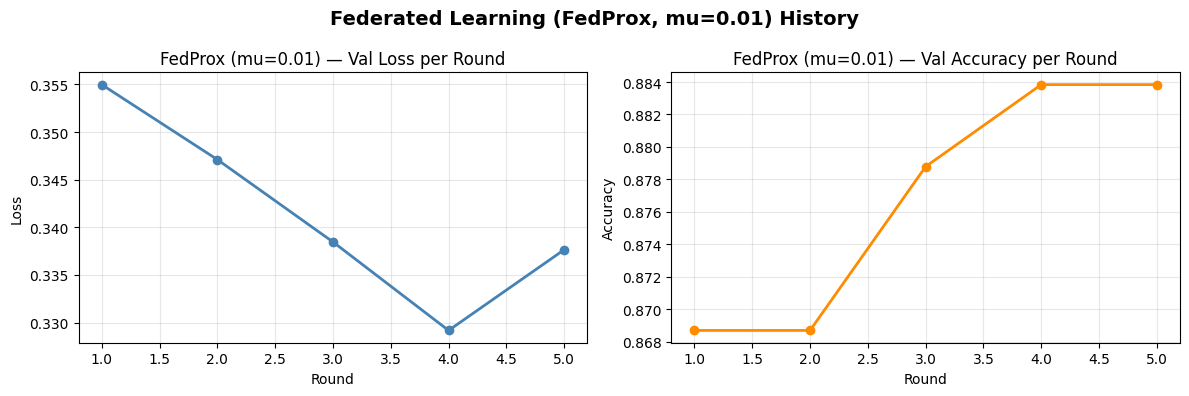

FedProx curves saved.


In [13]:
fl_hist_df = pd.read_csv(os.path.join(OUTPUT_DIR, "fl_fedprox_history.csv"))
print(fl_hist_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(fl_hist_df["round"], fl_hist_df["val_loss"], marker="o", linewidth=2, color="steelblue")
ax1.set_title(f"FedProx (mu={FEDPROX_MU}) — Val Loss per Round")
ax1.set_xlabel("Round"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2.plot(fl_hist_df["round"], fl_hist_df["val_acc"], marker="o", linewidth=2, color="darkorange")
ax2.set_title(f"FedProx (mu={FEDPROX_MU}) — Val Accuracy per Round")
ax2.set_xlabel("Round"); ax2.set_ylabel("Accuracy"); ax2.grid(True, alpha=0.3)

plt.suptitle(f"Federated Learning (FedProx, mu={FEDPROX_MU}) History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fl_fedprox_curves.png"), dpi=200)
plt.show()
print("FedProx curves saved.")


In [14]:
print("Loading best FedBN checkpoint for FINAL TEST evaluation...")
fl_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_fl_fedprox.pt"), map_location=DEVICE))
fl_model.eval()

te_loss, te_acc, te_f1, te_y, te_p = run_one_epoch(fl_model, test_loader, fl_criterion,
                                                     desc="Final test eval")

print("\n" + "="*65)
print("  FINAL TEST RESULTS  (held-out 10%)")
print("="*65)
print(f"  Test Loss : {te_loss:.4f}")
print(f"  Test Acc  : {te_acc:.4f}")
print(f"  Test F1   : {te_f1:.4f}")
print()
print(classification_report(te_y, te_p, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(te_y, te_p)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("FedProx — Final Test Confusion Matrix (10% held-out)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_confusion_matrix_fedprox.png"), dpi=200)
plt.close()
print("Confusion matrix saved.")


Loading best FedBN checkpoint for FINAL TEST evaluation...


Final test eval:   0%|          | 0/4 [00:00<?, ?it/s]


  FINAL TEST RESULTS  (held-out 10%)
  Test Loss : 0.3049
  Test Acc  : 0.9182
  Test F1   : 0.8519

                 precision    recall  f1-score   support

   Bengin cases     0.6000    0.7500    0.6667        12
Malignant cases     1.0000    1.0000    1.0000        56
   Normal cases     0.9231    0.8571    0.8889        42

       accuracy                         0.9182       110
      macro avg     0.8410    0.8690    0.8519       110
   weighted avg     0.9270    0.9182    0.9212       110

Confusion matrix saved.


Loading best FedProx checkpoint for FINAL TEST evaluation...


Final test eval:   0%|          | 0/4 [00:00<?, ?it/s]


  FINAL TEST RESULTS  (held-out 10%)
  Test Loss : 0.3049
  Test Acc  : 0.9182
  Test F1   : 0.8519

                 precision    recall  f1-score   support

   Bengin cases     0.6000    0.7500    0.6667        12
Malignant cases     1.0000    1.0000    1.0000        56
   Normal cases     0.9231    0.8571    0.8889        42

       accuracy                         0.9182       110
      macro avg     0.8410    0.8690    0.8519       110
   weighted avg     0.9270    0.9182    0.9212       110



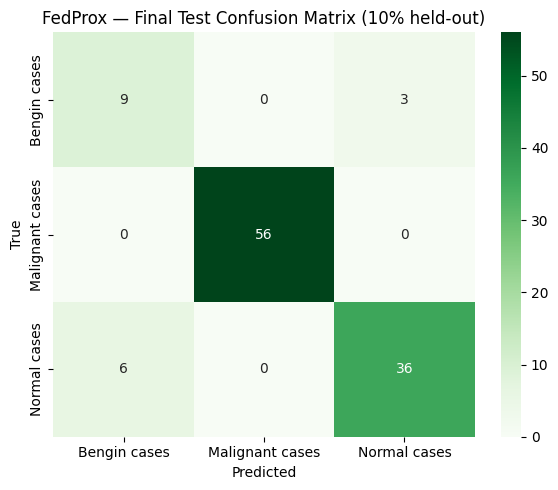

In [17]:
 print("Loading best FedProx checkpoint for FINAL TEST evaluation...")
fl_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_fl_fedprox.pt"), map_location=DEVICE))
fl_model.eval()

te_loss, te_acc, te_f1, te_y, te_p = run_one_epoch(fl_model, test_loader, fl_criterion,
                                                     desc="Final test eval")

print("\n" + "="*65)
print("  FINAL TEST RESULTS  (held-out 10%)")
print("="*65)
print(f"  Test Loss : {te_loss:.4f}")
print(f"  Test Acc  : {te_acc:.4f}")
print(f"  Test F1   : {te_f1:.4f}")
print()
print(classification_report(te_y, te_p, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(te_y, te_p)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("FedProx — Final Test Confusion Matrix (10% held-out)")
plt.tight_layout()
plt.show()

In [16]:
class GradCAM:
    def __init__(self, model, target_module):
        self.model = model
        self.gradients = self.activations = None
        self._fwd_handle = target_module.register_forward_hook(
            lambda m,i,o: setattr(self, "activations", o)   # keep graph attached, no .detach()
        )
        self._bwd_handle = target_module.register_full_backward_hook(
            lambda m,gi,go: setattr(self, "gradients", go[0].detach())
        )

    def __call__(self, raw_x, pre_x, class_idx=None):
        self.model.zero_grad()
        self.gradients = self.activations = None   # reset before each call

        # Must run forward/backward with grad enabled even if model is in eval()
        with torch.set_grad_enabled(True):
            raw_x = raw_x.clone().requires_grad_(True)
            pre_x = pre_x.clone().requires_grad_(True)
            logits = self.model(raw_x, pre_x)
            if class_idx is None:
                class_idx = logits.argmax(dim=1).item()
            score = logits[:, class_idx].sum()
            score.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError(
                "GradCAM hooks did not fire — check that target_module is part of "
                "the forward pass and that the model wasn't run under torch.no_grad()."
            )

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((weights * self.activations.detach()).sum(dim=1, keepdim=True))
        cam = torch.nn.functional.interpolate(cam, size=raw_x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

fl_model.eval()
raw_x, pre_x, y = test_ds[0]
raw_in = raw_x.unsqueeze(0).to(DEVICE)
pre_in = pre_x.unsqueeze(0).to(DEVICE)

cam_engine = GradCAM(fl_model, fl_model.raw_features[-1])
cam, pred_idx = cam_engine(raw_in, pre_in)

print(f"Grad-CAM sample → True: {CLASS_NAMES[y]}  |  Predicted: {CLASS_NAMES[pred_idx]}")

img = raw_x.permute(1,2,0).numpy()
img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off")
plt.title(f"True: {CLASS_NAMES[y]}  |  Pred: {CLASS_NAMES[pred_idx]}")
plt.subplot(1,2,2); plt.imshow(img); plt.imshow(cam, cmap="jet", alpha=0.45); plt.axis("off")
plt.title("Grad-CAM (FedProx — Test Sample)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_fedprox_test.png"), dpi=200)
plt.close()
print("Grad-CAM saved.")

Grad-CAM sample → True: Normal cases  |  Predicted: Normal cases
Grad-CAM saved.



=== Grad-CAM — Bengin cases (3 samples) ===
  Sample 1: True=Bengin cases Pred=Normal cases
  Sample 2: True=Bengin cases Pred=Normal cases
  Sample 3: True=Bengin cases Pred=Bengin cases


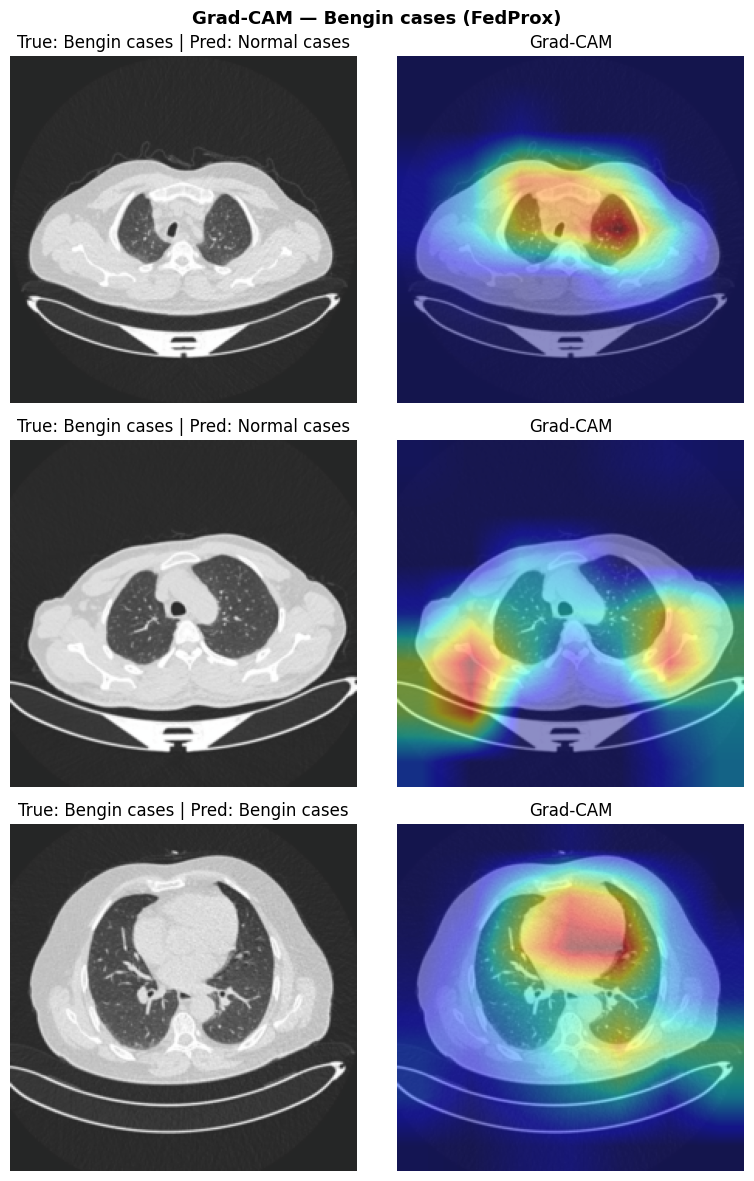


=== Grad-CAM — Malignant cases (3 samples) ===
  Sample 1: True=Malignant cases Pred=Malignant cases
  Sample 2: True=Malignant cases Pred=Malignant cases
  Sample 3: True=Malignant cases Pred=Malignant cases


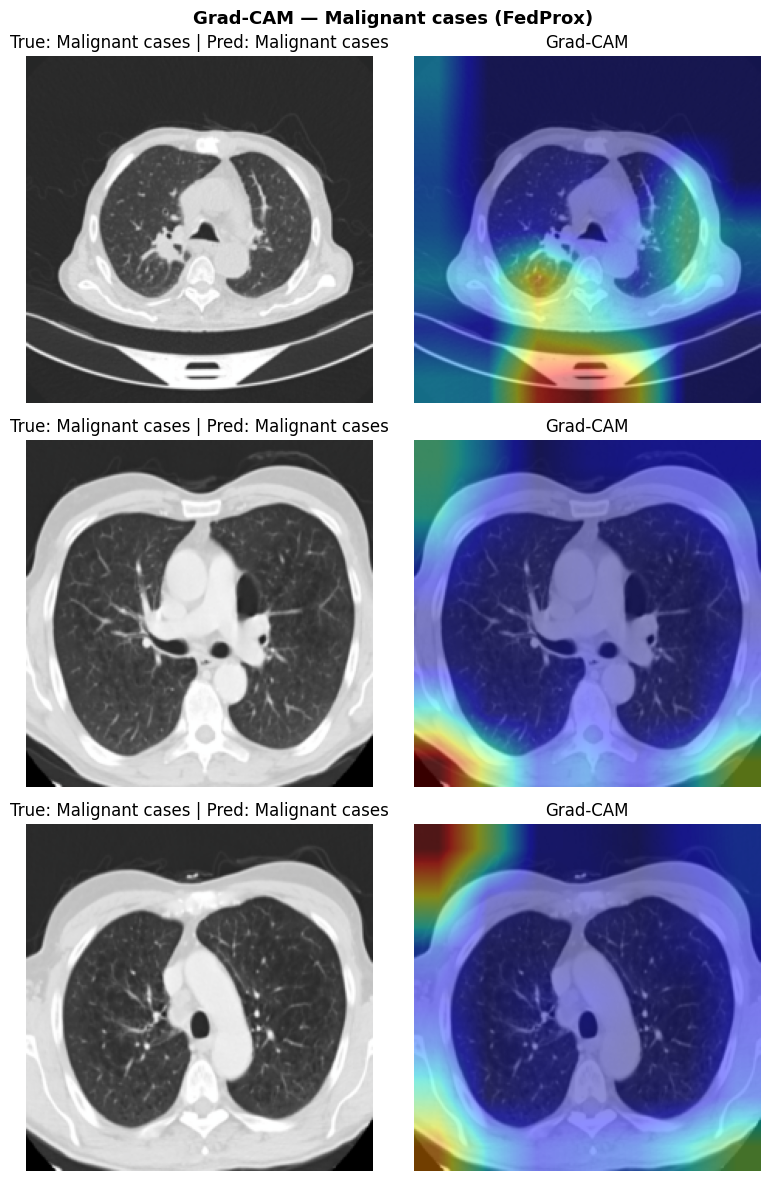


=== Grad-CAM — Normal cases (3 samples) ===
  Sample 1: True=Normal cases Pred=Normal cases
  Sample 2: True=Normal cases Pred=Normal cases
  Sample 3: True=Normal cases Pred=Normal cases


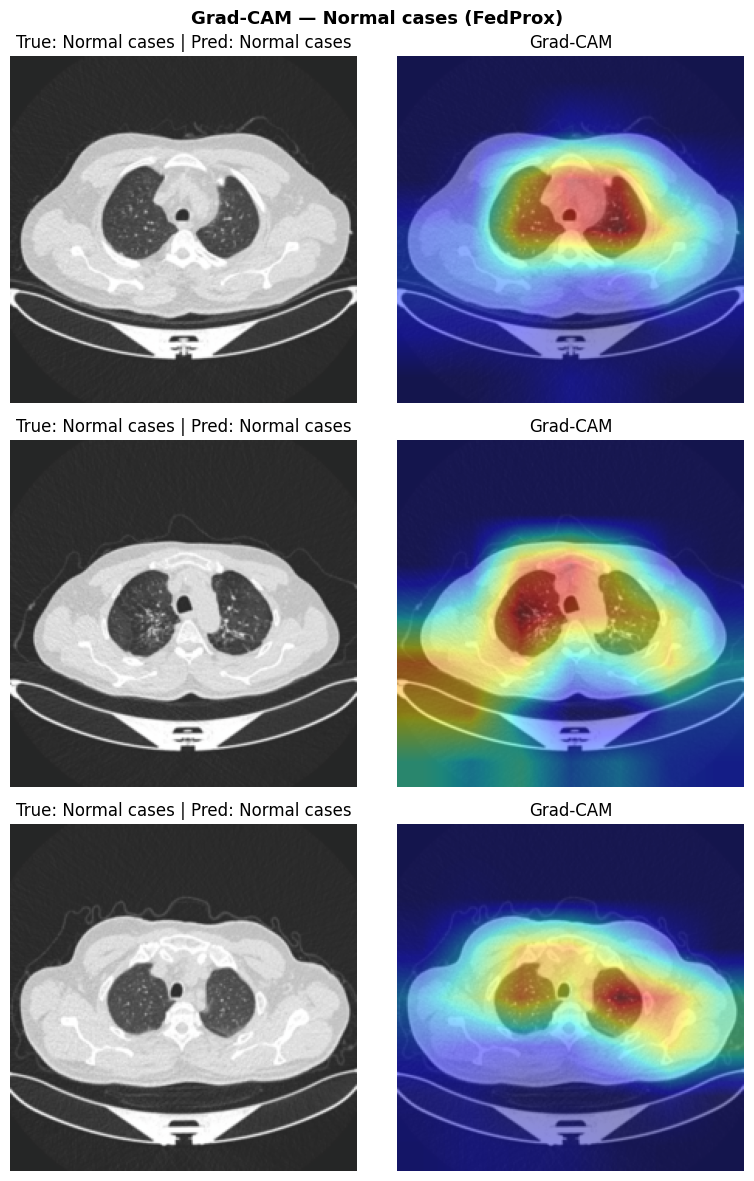

In [18]:
class GradCAM:
    def __init__(self, model, target_module):
        self.model = model
        self.gradients = self.activations = None
        target_module.register_forward_hook(
            lambda m,i,o: setattr(self, "activations", o)
        )
        target_module.register_full_backward_hook(
            lambda m,gi,go: setattr(self, "gradients", go[0].detach())
        )

    def __call__(self, raw_x, pre_x, class_idx=None):
        self.model.zero_grad()
        self.gradients = self.activations = None

        with torch.set_grad_enabled(True):
            raw_x = raw_x.clone().requires_grad_(True)
            pre_x = pre_x.clone().requires_grad_(True)
            logits = self.model(raw_x, pre_x)
            if class_idx is None:
                class_idx = logits.argmax(dim=1).item()
            logits[:, class_idx].sum().backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("GradCAM hooks did not fire.")

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((weights * self.activations.detach()).sum(dim=1, keepdim=True))
        cam = torch.nn.functional.interpolate(cam, size=raw_x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def denorm(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)


fl_model.eval()
cam_engine = GradCAM(fl_model, fl_model.raw_features[-1])

SAMPLES_PER_CLASS = 3

# Group test_samples indices by class
class_to_indices = {c: [] for c in range(NUM_CLASSES)}
for idx, (_, label) in enumerate(test_samples):
    class_to_indices[label].append(idx)

for class_idx in range(NUM_CLASSES):
    indices = class_to_indices[class_idx][:SAMPLES_PER_CLASS]
    if not indices:
        print(f"No test samples for class '{CLASS_NAMES[class_idx]}'")
        continue

    print(f"\n=== Grad-CAM — {CLASS_NAMES[class_idx]} ({len(indices)} samples) ===")
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, 2)

    for row, idx in enumerate(indices):
        raw_x, pre_x, y = test_ds[idx]
        raw_in = raw_x.unsqueeze(0).to(DEVICE)
        pre_in = pre_x.unsqueeze(0).to(DEVICE)

        cam, pred_idx = cam_engine(raw_in, pre_in)
        img = denorm(raw_x)

        axes[row, 0].imshow(img); axes[row, 0].axis("off")
        axes[row, 0].set_title(f"True: {CLASS_NAMES[y]} | Pred: {CLASS_NAMES[pred_idx]}")

        axes[row, 1].imshow(img); axes[row, 1].imshow(cam, cmap="jet", alpha=0.45); axes[row, 1].axis("off")
        axes[row, 1].set_title("Grad-CAM")

        print(f"  Sample {row+1}: True={CLASS_NAMES[y]} Pred={CLASS_NAMES[pred_idx]}")

    plt.suptitle(f"Grad-CAM — {CLASS_NAMES[class_idx]} (FedProx)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()